In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.shape

(301, 9)

In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [5]:
df = df.drop_duplicates()

In [6]:
df["Fuel_Type"] = df["Fuel_Type"].str.title()
df["Seller_Type"] = df["Seller_Type"].str.title()
df["Transmission"] = df["Transmission"].str.title()

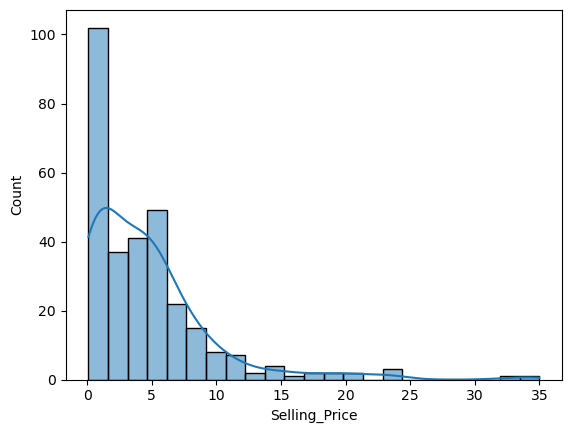

In [7]:
sns.histplot(df["Selling_Price"], kde=True)
plt.savefig("histplot.png", dpi=300, bbox_inches="tight")
plt.show()

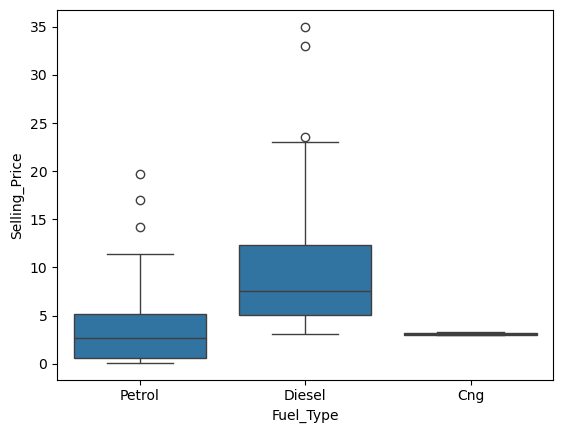

In [8]:
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.savefig("boxplot3.png", dpi=300, bbox_inches="tight")
plt.show()

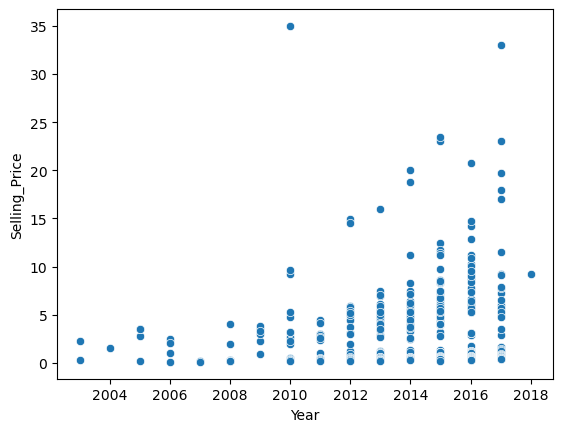

In [9]:
sns.scatterplot(x="Year", y="Selling_Price", data=df)
plt.savefig("scatterplt.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
le = LabelEncoder()

for col in ["Fuel_Type","Seller_Type","Transmission","Car_Name"]:
    df[col] = le.fit_transform(df[col])

In [11]:
df = df.drop(["Car_Name","Year"], axis=1)


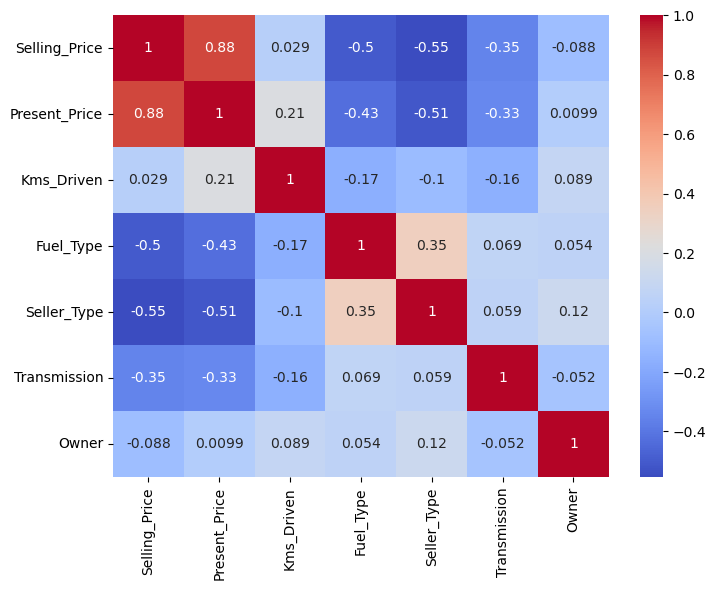

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.savefig("heatmap3.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [15]:
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred)**0.5)
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 1.6661424592042537
RMSE: 3.0577761980303824
R2: 0.6372211171165059


In [16]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [17]:
print("Random Forest")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred)**0.5)
print("R2:", r2_score(y_test, rf_pred))

Random Forest
MAE: 1.4318780952380954
RMSE: 3.204019600828593
R2: 0.6016902511610467


In [18]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

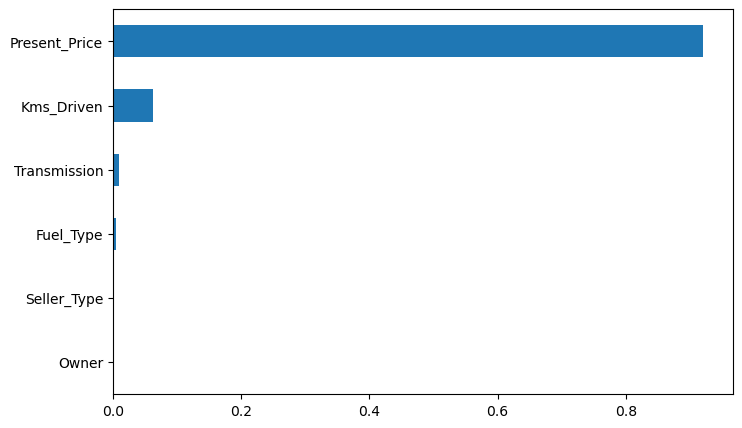

In [19]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.savefig("bar.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "R2":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,R2
0,Linear Regression,0.637221
1,Random Forest,0.601690
